# Chapter2: 数値積分の実装

## 2.1 簡単な 1階の常備分方程式の数値解法

### 2.1.1 オイラー法について

微分方程式 $dy/dx = \cos(x)$ を解きたい．この解析解は初期値 $(x(0), y(0)) = (0, 0)$ とすると，$y = \sin(x)$ だが，これがわからないとして，数値的に解くことを考えたい．

↓ 求めたい真の関数 $y = \sin(x)$

・まず numpy matplotlib を使って三角関数を描画

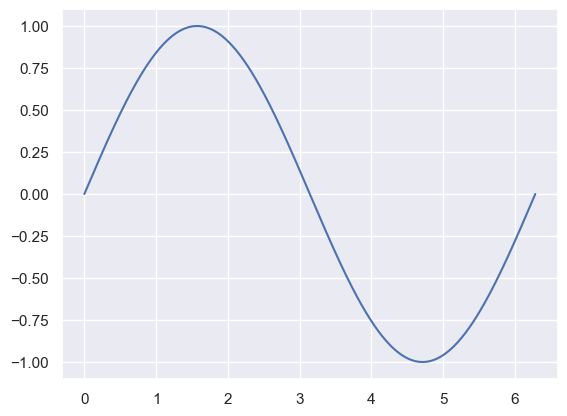

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

x_1000 = np.linspace(0, 2*np.pi, 1000)
y_sin = np.sin(x_1000)

sns.set()

plt.plot(x_1000, y_sin)

・オイラー法による数値積分

微分方程式： $dy/dx = \cos(x)$

初期条件：$(x(0), y(0)) = (0, 0)$

刻み幅$\Delta$：$[0, 2\pi]$ を 30 分割してみる

オイラー法による数値積分の結果と，解析解 $y=\sin x$ を重ねてプロットしてみてください．

In [18]:
def dydx_cos(x_inp):
    dydx = np.cos(x_inp)
    return dydx

def euler_cos(dx):
    x_positive = np.linspace(0, 2*np.pi, dx)
    delta = x_positive[1] - x_positive[0]

    dydx_value = dydx_cos(x_positive)
    y_euler = np.zeros(1)

    for i in range(len(x_positive) - 1):
        y_next = y_euler[i] + delta * dydx_value[i]
        y_euler = np.append(y_euler, y_next)

    plt.plot(x_positive, y_euler, label='euler')
    plt.plot(x_1000, y_sin, label='sin')
    plt.legend()
    return x_positive, y_euler

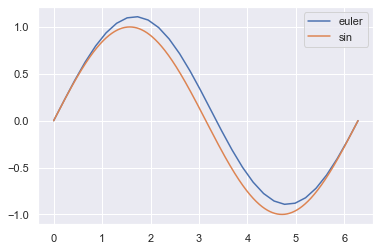

In [19]:
e_30_x, e_30_y = euler_cos(30)

分割の数を増減させると結果はどうなりますか？

幅を 10, 1000 としてもう一度計算してみましょう


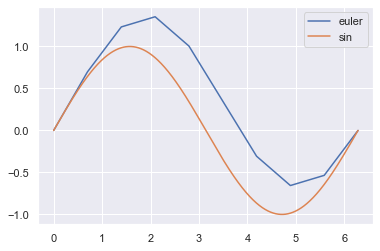

In [27]:
e_10_x, e_10_y = euler_cos(10)

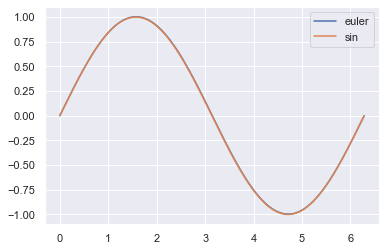

In [21]:
e_1000_x, e_1000_y = euler_cos(1000)

---

### 2.1.2 Runge–Kutta 法について

オイラー法は数値積分法としてはかなり初歩的で単純な方法でした．

次に，RUnge-Kutta 法と呼ばれる別の数値積分法で，同じ関数・同じ初期条件について解いてみることにしましょう．

In [22]:
# Runge-Kutta法 の 1 ステップ
def calc_runge_kutta(y_n, x_n, h):
    
    k_1 = dydx_cos((x_n))
    k_2 = dydx_cos((x_n + h/2))
    k_3 = dydx_cos((x_n + h/2))
    k_4 = dydx_cos((x_n + h))

    y_n_1 = y_n + h * (k_1 + 2 * k_2 + 2 *  k_3 + k_4) / 6

    return y_n_1

In [23]:
def rk_cos(dx):
    y_runge = np.zeros(1)
    x_positive = np.linspace(0, 2*np.pi, dx)
    delta = x_positive[1] - x_positive[0]

    for i in range(len(x_positive) - 1):
        y_next = calc_runge_kutta(y_runge[i], x_positive[i], delta)
        y_runge = np.append(y_runge, y_next)


    plt.plot(x_positive, y_runge, label='runge')
    plt.plot(x_1000, y_sin, label='sin')

    plt.legend()
    return x_positive, y_runge

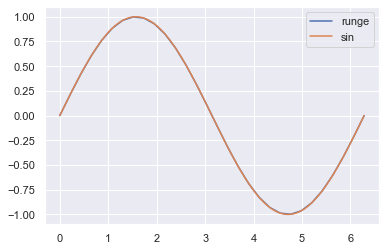

In [24]:
r_30_x, r_30_y = rk_cos(30)

分割の幅を変えてみる．幅を10にするとどうなりますか？

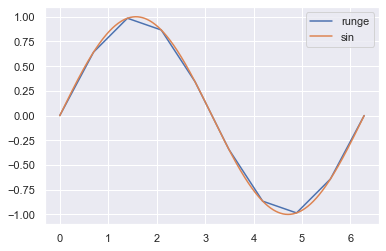

In [26]:
r_10_x, r_10_y = rk_cos(10)

Euler法とRunge-Kutta法の，分割の幅10の結果を比べてみる．

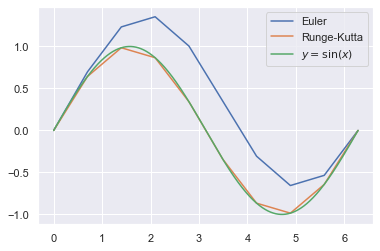

In [30]:
plt.plot(e_10_x, e_10_y, label='Euler')
plt.plot(r_10_x, r_10_y, label='Runge-Kutta')
plt.plot(x_1000, y_sin, label='$y=\sin(x)$')
plt.legend()

#### 補足 1

jupyter notebook では計算の実行時間を，セルの頭に %time とつけることでセルの実行時間を計測できます．

・%%time と %%timeit の違いは？

・この方法はjupyter notebookのマジックコマンドと言います．他にどんなマジックコマンドがあるでしょうか．

せっかくなので，Euler法とRunge-Kutta法で，刻み幅を10000にした時の実行時間を比較してみましょう．

In [2]:
%%time
e_10m_x, e_10m_y = euler_cos(10000)

NameError: name 'euler_cos' is not defined

CPU times: user 170 ms, sys: 7.09 ms, total: 177 ms
Wall time: 174 ms


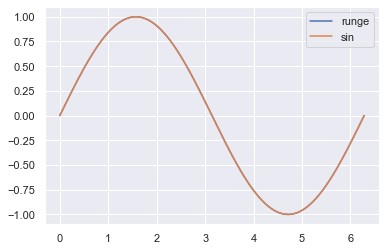

In [32]:
%%time
r_10m_x, r_10m_y = rk_cos(10000)

---